In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from datetime import datetime
from pytz import timezone, utc
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
from pytz import timezone

In [21]:
# --- Parameters ---
original_root = "/Volumes/External/TJ_SAR/02_preprocessed/02_JunethroughDec2024"
mask_root = "/Volumes/External/TJ_SAR/04_iseg"
output_plot_dir = "/Volumes/External/TJ_SAR/05_viz"
met_csv_path = "/Volumes/External/TJ_estuary/analysis/TJRTLMET.csv"

In [22]:
pacific = timezone("US/Pacific")
# --- Load meteorological data (in Pacific Time) ---
met_df = pd.read_csv(met_csv_path)
met_df.columns = met_df.columns.str.strip()

met_df["DateTimeStamp"] = pd.to_datetime(
    met_df["DateTimeStamp"], format="%m/%d/%y %H:%M", errors="coerce"
)
met_df["DateTimeStamp"] = met_df["DateTimeStamp"].dt.tz_localize(
    pacific,
    ambiguous="NaT",     # handle fall-back (ambiguous) times
    nonexistent="NaT"    # handle spring-forward (nonexistent) times
)
met_df = met_df.dropna(subset=["DateTimeStamp"])

met_df = met_df.sort_values("DateTimeStamp")


In [23]:
def extract_datetime_from_filename(filename):
    """Extract UTC datetime from Sentinel-1 filename."""
    parts = filename.split("_")
    for part in parts:
        if part.startswith("20") and "T" in part:
            try:
                return utc.localize(datetime.strptime(part, "%Y%m%dT%H%M%S"))
            except ValueError:
                continue
    return None

def get_nearest_met_data(local_time):
    """Find the closest met record to the given local time."""
    time_deltas = (met_df["DateTimeStamp"] - local_time).abs()
    nearest_idx = time_deltas.idxmin()
    row = met_df.loc[nearest_idx]
    return row["WSpd"], row["Wdir"], row["DateTimeStamp"]

def match_original_path(mask_filename):
    return os.path.join(original_root, mask_filename.replace("_JPL0.4_VVDR_cumulative_mask.tif", ".tif"))

In [29]:
def plot_overlay(original_path, mask_path, output_path):
    # --- Extract and convert image time ---
    image_time_utc = extract_datetime_from_filename(os.path.basename(original_path))
    image_time_local = image_time_utc.astimezone(pacific)

    # --- Match meteorological data ---
    wspd, wdir, met_time = get_nearest_met_data(image_time_local)

    # --- Read images ---
    with rasterio.open(original_path) as src:
        original = src.read(1)
        bounds = src.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    # --- Normalize image using standard deviation scaling ---
    mean = np.nanmean(original)
    std = np.nanstd(original)
    z_scaled = (original - mean) / std
    clipped = np.clip(z_scaled, -2, 2)
    normed = (clipped + 2) / 4  # Scale to [0, 1]

    # --- Set up side-by-side figure ---
    fig, axes = plt.subplots(1, 2, figsize=(9, 12), constrained_layout=True)

    # Left: original only
    axes[0].imshow(normed, cmap="gray", extent=extent)
    axes[0].set_title("Original (Normalized)", fontsize=12)
    axes[0].axis('off')

    # Right: original + mask
    axes[1].imshow(normed, cmap="gray", extent=extent)

    # mask out all zero pixels so they won’t be drawn
    masked = np.ma.masked_where(mask == 0, mask)


    # 1. Make a boolean mask
    mask_bin = (mask > 0)

    # 2. Build an RGBA overlay array:
    #    R=1, G=1, B=0.8 (light yellow), A=0.5 (50% opaque)
    overlay = np.zeros((mask.shape[0], mask.shape[1], 4))
    overlay[mask_bin] = [1.0, 1.0, 0.8, 1.0]

    # 3. Draw it on top
    axes[1].imshow(overlay, extent=extent)

    axes[1].set_title("Original with Plume Mask", fontsize=12)
    axes[1].axis('off')


    # --- Bottom annotation: wind info + local time ---
    wind_text = (
        f"Wind: {wspd:.1f} m/s @ {wdir:.0f}°\n"
        f"Local Time: {image_time_local.strftime('%Y-%m-%d %H:%M')}"
    )
    fig.text(0.5, 0.15, wind_text, ha='center', fontsize=13, fontweight='bold')


    # --- Wind vector in real coordinates ---
    import matplotlib.patches as patches
    import math


    # --- Compute arrow parameters ---
    wind_angle_deg = (270 - wdir) % 360  # convert "from" to math angle
    angle_rad = math.radians(wind_angle_deg)

    # Get image height (in spatial units)
    height = bounds.top - bounds.bottom

    # Base arrow length as % of image height, scaled by wind speed
    base_frac = 0.07  # base length = 7% of image height
    scale = np.clip(wspd / 10, 0.5, 1.5)  # scale between 50%–150%
    arrow_length = height * base_frac * scale

    # Arrow vector
    dx = arrow_length * math.cos(angle_rad)
    dy = arrow_length * math.sin(angle_rad)

    # Starting point (near bottom-right of image)
    x0 = bounds.right - 0.1 * (bounds.right - bounds.left)
    y0 = bounds.bottom + 0.05 * height

    # --- Draw the arrow ---
    axes[1].add_patch(
        patches.FancyArrow(
            x0, y0, dx, dy,
            width=arrow_length * 0.05,
            head_width=arrow_length * 0.15,
            head_length=arrow_length * 0.15,
            length_includes_head=True,
            transform=axes[1].transData,
            color='lime',
            alpha=0.9
        )
    )

    # --- Save plot ---
    os.makedirs(output_plot_dir, exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

In [30]:
# --- Main processing loop ---
for root, _, files in os.walk(mask_root):
    for file in files:
        if file.startswith('.'):
            continue
        if file.endswith("_JPL0.4_VVDR_cumulative_mask.tif"):
            mask_path = os.path.join(root, file)
            original_path = match_original_path(file)

            if os.path.exists(original_path):
                flat_name = file.replace("_JPL0.4_VVDR_cumulative_mask.tif", "_overlay.png")
                output_path = os.path.join(output_plot_dir, flat_name)
                plot_overlay(original_path, mask_path, output_path)
            else:
                print(f"[!] Original image not found for: {file}")

print("Done!")

Saved: /Users/ereilly/Documents/code/autoSAR_preprocessing/plotted_images/S1A_IW_GRDH_1SDV_20241216T015014_20241216T015043_057011_070161_E8F2_pre_overlay.png
Saved: /Users/ereilly/Documents/code/autoSAR_preprocessing/plotted_images/S1A_IW_GRDH_1SDV_20241129T134455_20241129T134520_056770_06F7DB_D673_pre_overlay.png
Saved: /Users/ereilly/Documents/code/autoSAR_preprocessing/plotted_images/S1A_IW_GRDH_1SDV_20241110T135319_20241110T135344_056493_06ECD4_BBBF_pre_overlay.png
Saved: /Users/ereilly/Documents/code/autoSAR_preprocessing/plotted_images/S1A_IW_GRDH_1SDV_20241017T015017_20241017T015046_056136_06DE9F_4EAA_pre_overlay.png
Saved: /Users/ereilly/Documents/code/autoSAR_preprocessing/plotted_images/S1A_IW_GRDH_1SDV_20240830T015015_20240830T015045_055436_06C312_73FC_pre_overlay.png
Saved: /Users/ereilly/Documents/code/autoSAR_preprocessing/plotted_images/S1A_IW_GRDH_1SDV_20241029T015017_20241029T015046_056311_06E595_EEAE_pre_overlay.png
Saved: /Users/ereilly/Documents/code/autoSAR_preproc

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import rasterio.features
import geopandas as gpd
import math
from shapely.geometry import shape
from datetime import datetime
from pytz import timezone, utc
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize
import matplotlib.patches as patches
import pybuoy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- Parameters ---
original_root = '/Volumes/External/TJ_SAR/02_preprocessed/02_20202025'
mask_root = '/Volumes/External/TJ_SAR/04_iseg'
output_plot_dir = '/Volumes/External/TJ_SAR/05_viz/test'
output_shapefile_dir = '/Volumes/External/TJ_SAR/06_shapefiles'
met_csv_path = '/Volumes/External/TJ_estuary/analysis/TJRTLMET.csv'
threshold = 0  # only keep mask values > threshold

# --- New: Path to point-data shapefile ---
point_shapefile_path = '/Volumes/External/TJ_SAR/01_data/shapefiles/Outflow.shp'

# timezones
pacific = timezone('US/Pacific')

# --- Load meteorological data (in Pacific Time) ---
met_df = pd.read_csv(met_csv_path)
met_df.columns = met_df.columns.str.strip()
met_df['DateTimeStamp'] = pd.to_datetime(
    met_df['DateTimeStamp'], format='%m/%d/%y %H:%M', errors='coerce'
)
met_df['DateTimeStamp'] = met_df['DateTimeStamp'].dt.tz_localize(
    pacific,
    ambiguous='NaT',
    nonexistent='NaT'
)
met_df = met_df.dropna(subset=['DateTimeStamp']).sort_values('DateTimeStamp')

# --- Load point data once ---
points_gdf_orig = gpd.read_file(point_shapefile_path)

# --- Initialize buoy client and station ---
buoy = pybuoy.Buoy()
closest_station = '46235'  # fixed station choice
print(f"→ Using fixed buoy: {closest_station}")

# --- Utility functions ---
def extract_datetime_from_filename(filename):
    '''Extract UTC datetime from Sentinel-1 filename.'''
    parts = filename.split('_')
    for part in parts:
        if part.startswith('20') and 'T' in part:
            try:
                return utc.localize(datetime.strptime(part, '%Y%m%dT%H%M%S'))
            except ValueError:
                continue
    return None


def get_nearest_met_data(local_time):
    '''Find the closest met record to the given local time.'''
    diffs = (met_df['DateTimeStamp'] - local_time).abs()
    idx = diffs.idxmin()
    row = met_df.loc[idx]
    return row['WSpd'], row['Wdir'], row['DateTimeStamp']


def get_nearest_wave_data(image_time_local):
    '''
    Returns (swell_height_m, swell_dir_deg) from the nearest
    spec dataset observation at our chosen station.
    '''
    wave_obs = buoy.realtime.get(
        station_id=closest_station,
        dataset='spec'
    )
    best = None
    best_dt = None
    for obs in wave_obs:
        obs_time = utc.localize(obs.datetime).astimezone(pacific)
        dt = abs(obs_time - image_time_local)
        if best is None or dt < best_dt:
            best, best_dt = obs, dt
    if best is None:
        return None, None
    return best.swell_height.value, best.dominant_wave_direction.value


def match_original_path(mask_filename):
    return os.path.join(
        original_root,
        mask_filename.replace('_JPL0.4_VVDR_cumulative_mask.tif', '.tif')
    )

# --- Main processing loop ---
# make sure output dirs exist
os.makedirs(output_plot_dir, exist_ok=True)
os.makedirs(output_shapefile_dir, exist_ok=True)

for root, _, files in os.walk(mask_root):
    for file in files:
        if file.startswith('.') or not file.endswith('_JPL0.4_VVDR_cumulative_mask.tif'):
            continue

        mask_path = os.path.join(root, file)
        original_path = match_original_path(file)

        if not os.path.exists(original_path):
            print(f'[!] Original image not found for: {file}')
            continue

        # --- Read mask and prepare shapefile export ---
        with rasterio.open(mask_path) as src_mask:
            mask_arr = src_mask.read(1)
            transform = src_mask.transform
            crs = src_mask.crs
            nodata = src_mask.nodata

        # Build boolean mask: pixels > threshold and not nodata
        valid_mask = mask_arr > threshold
        if nodata is not None:
            valid_mask &= (mask_arr != nodata)

        # Vectorize mask to shapes
        shapes = []
        for geom, val in rasterio.features.shapes(
            mask_arr.astype('int16'),
            mask=valid_mask,
            transform=transform
        ):
            shapes.append({'geometry': shape(geom), 'value': int(val)})

        # Write GeoDataFrame if any shapes found
        if shapes:
            gdf = gpd.GeoDataFrame(shapes, crs=crs)
            shp_name = file.replace(
                '_JPL0.4_VVDR_cumulative_mask.tif', '_mask.shp'
            )
            out_shp = os.path.join(output_shapefile_dir, shp_name)
            gdf.to_file(out_shp, driver='ESRI Shapefile')
            print(f'  → wrote shapefile: {out_shp}')
        else:
            print(f'  → no valid mask pixels for: {file}, skipping shapefile.')

        # --- Read original for plotting and get meteorology & swell ---
        image_time_utc = extract_datetime_from_filename(file)
        image_time_local = image_time_utc.astimezone(pacific)
        wspd, wdir, met_time = get_nearest_met_data(image_time_local)
        swell_h, swell_dir = get_nearest_wave_data(image_time_local)

        with rasterio.open(original_path) as src_orig:
            original = src_orig.read(1).astype(float)
            bounds = src_orig.bounds
            extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

        # Stretch original reflectance
        vmin, vmax = np.nanpercentile(original, (2, 95))
        clipped = np.clip(original, vmin, vmax)
        normed = (clipped - vmin) / (vmax - vmin)

        # Build RGBA overlay
        overlay = np.zeros((mask_arr.shape[0], mask_arr.shape[1], 4))
        overlay[valid_mask] = [1.0, 1.0, 0.8, 1.0]

        # Reproject points to match image CRS
        points_gdf = points_gdf_orig.to_crs(crs)

        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(9, 12), constrained_layout=True)

        # left: original
        axes[0].imshow(normed, cmap='gray', extent=extent)
        points_gdf.plot(
            ax=axes[0], marker='o', color='red', markersize=5, label='Points'
        )
        axes[0].set_title('Original (2–98% Stretch)', fontsize=12)
        axes[0].axis('off')

        # right: with mask overlay
        axes[1].imshow(normed, cmap='gray', extent=extent)
        axes[1].imshow(overlay, extent=extent)
        points_gdf.plot(ax=axes[1], marker='o', color='red', markersize=5)
        axes[1].set_title('Original with Plume Mask', fontsize=12)
        axes[1].axis('off')

        # Annotation and wind vector
        wind_text = (
            f'Wind: {wspd:.1f} m/s @ {wdir:.0f}°\n'
            f'Local Time: {image_time_local.strftime('%Y-%m-%d %H:%M')}'
        )
        fig.text(0.5, 0.15, wind_text, ha='center', fontsize=13, fontweight='bold')
        wind_angle_deg = (270 - wdir) % 360
        angle_rad = math.radians(wind_angle_deg)
        height = bounds.top - bounds.bottom
        base_frac = 0.07
        scale = np.clip(wspd / 10, 0.5, 1.5)
        arrow_length = height * base_frac * scale
        dx = arrow_length * math.cos(angle_rad)
        dy = arrow_length * math.sin(angle_rad)
        x0 = bounds.right - 0.1 * (bounds.right - bounds.left)
        y0 = bounds.bottom + 0.05 * height
        axes[1].add_patch(
            patches.FancyArrow(
                x0, y0, dx, dy,
                width=arrow_length * 0.05,
                head_width=arrow_length * 0.15,
                head_length=arrow_length * 0.15,
                length_includes_head=True,
                transform=axes[1].transData,
                color='lime',
                alpha=0.9
            )
        )

        # add a little polar bar for swell
        if swell_h is not None:
            ax_swell = fig.add_axes([0.65, 0.75, 0.25, 0.25], projection='polar')
            ax_swell.set_theta_zero_location('N')
            ax_swell.set_theta_direction(-1)
            theta = math.radians((270 - swell_dir) % 360)
            ax_swell.bar(theta, swell_h, width=0.5, bottom=0.0, alpha=0.7)
            ax_swell.set_title('Swell', fontsize=10)
            ax_swell.set_yticks([])
            ax_swell.set_xticks([0, math.pi/2, math.pi, 3*math.pi/2])
            ax_swell.set_xticklabels(['N','E','S','W'], fontsize=8)

        # Save figure
        flat_name = file.replace(
            '_JPL0.4_VVDR_cumulative_mask.tif', '_overlay.png'
        )
        out_png = os.path.join(output_plot_dir, flat_name)
        os.makedirs(os.path.dirname(out_png), exist_ok=True)
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  → saved plot: {out_png}')

print('Done!')


→ Using fixed buoy: 46235
  → no valid mask pixels for: S1A_IW_GRDH_1SDV_20221121T015015_20221121T015044_045986_0580C5_7D6E_pre_JPL0.4_VVDR_cumulative_mask.tif, skipping shapefile.
  → saved plot: /Volumes/External/TJ_SAR/05_viz/test/S1A_IW_GRDH_1SDV_20221121T015015_20221121T015044_045986_0580C5_7D6E_pre_overlay.png
  → wrote shapefile: /Volumes/External/TJ_SAR/06_shapefiles/S1A_IW_GRDH_1SDV_20221121T135317_20221121T135342_045993_058110_4619_pre_mask.shp
  → saved plot: /Volumes/External/TJ_SAR/05_viz/test/S1A_IW_GRDH_1SDV_20221121T135317_20221121T135342_045993_058110_4619_pre_overlay.png
  → no valid mask pixels for: S1A_IW_GRDH_1SDV_20221128T134454_20221128T134519_046095_05847D_4A73_pre_JPL0.4_VVDR_cumulative_mask.tif, skipping shapefile.


  → wrote shapefile: /Volumes/External/TJ_SAR/06_shapefiles/wide_gooddays/S1A_IW_GRDH_1SDV_20221203T015015_20221203T015044_046161_0586BC_72DC_pre_mask.shp
  → saved plot: /Volumes/External/TJ_SAR/05_viz/wide_gooddays/S1A_IW_GRDH_1SDV_20221203T015015_20221203T015044_046161_0586BC_72DC_pre_overlay_2.png
  → wrote shapefile: /Volumes/External/TJ_SAR/06_shapefiles/wide_gooddays/S1A_IW_GRDH_1SDV_20221215T015014_20221215T015043_046336_058CB1_E040_pre_mask.shp


KeyboardInterrupt: 

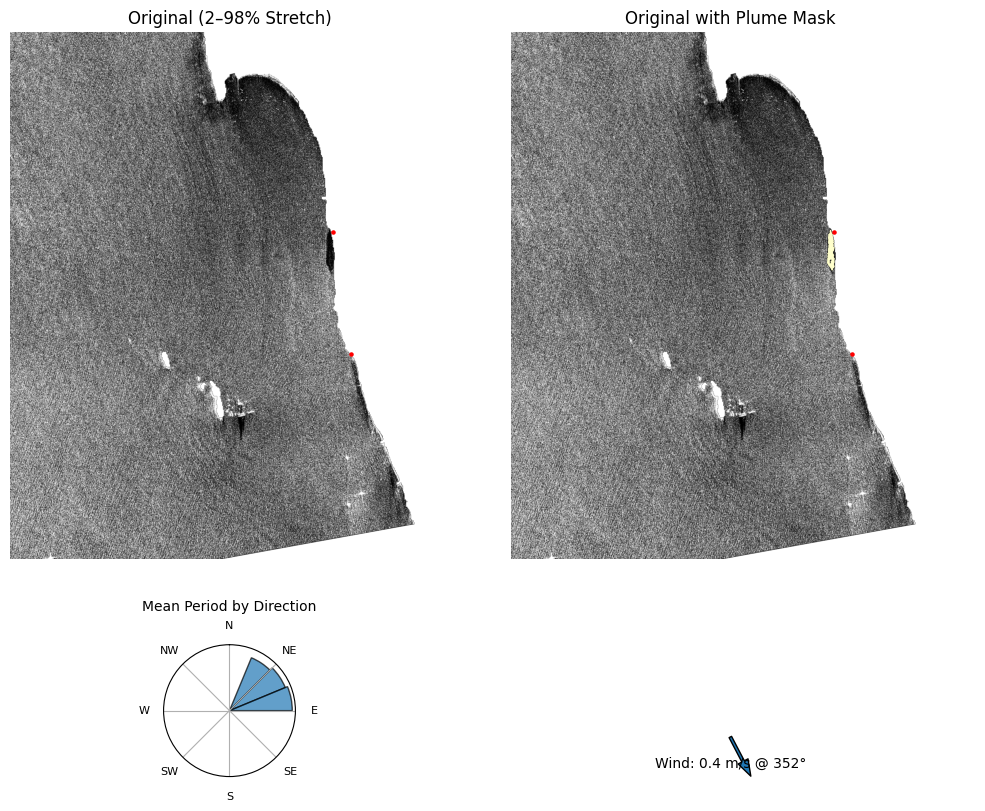

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import rasterio.features
import geopandas as gpd
import math
from shapely.geometry import shape
from datetime import datetime
from pytz import timezone, utc
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import netCDF4
import calendar
import matplotlib.gridspec as gridspec

# --- Parameters ---
original_root = '/Volumes/External/TJ_SAR/02_preprocessed/background_gooddays'
mask_root = '/Volumes/External/TJ_SAR/04_iseg/wide_gooddays'


output_plot_dir = '/Volumes/External/TJ_SAR/05_viz/wide_gooddays'
output_shapefile_dir = '/Volumes/External/TJ_SAR/06_shapefiles/wide_gooddays'
met_csv_path = '/Volumes/External/TJ_estuary/analysis/TJRTLMET.csv'
threshold = 0  # only keep mask values > threshold
point_shapefile_path = '/Volumes/External/TJ_SAR/01_data/shapefiles/Outflow.shp'

# CDIP station and window (days before acquisition)
stn = '198'
window_days = 1

# timezones
pacific = timezone('US/Pacific')

# --- Load meteorological data (in Pacific Time) ---
met_df = pd.read_csv(met_csv_path)
met_df.columns = met_df.columns.str.strip()
met_df['DateTimeStamp'] = pd.to_datetime(
    met_df['DateTimeStamp'], format='%m/%d/%y %H:%M', errors='coerce'
)
met_df['DateTimeStamp'] = met_df['DateTimeStamp'].dt.tz_localize(
    pacific,
    ambiguous='NaT',
    nonexistent='NaT'
)
met_df = met_df.dropna(subset=['DateTimeStamp']).sort_values('DateTimeStamp')

# --- Load point data once ---
points_gdf_orig = gpd.read_file(point_shapefile_path)

# --- Helper functions ---
def extract_datetime_from_filename(filename):
    parts = filename.split('_')
    for part in parts:
        if part.startswith('20') and 'T' in part:
            try:
                return utc.localize(datetime.strptime(part, '%Y%m%dT%H%M%S'))
            except ValueError:
                continue
    return None


def get_nearest_met_data(local_time):
    diffs = (met_df['DateTimeStamp'] - local_time).abs()
    idx = diffs.idxmin()
    row = met_df.loc[idx]
    return row['WSpd'], row['Wdir'], row['DateTimeStamp']


def match_original_path(mask_filename):
    return os.path.join(
        original_root,
        mask_filename.replace('_JPL0.4_VVDR_cumulative_mask.tif', '.tif')
    )

# CDIP time helpers
def find_nearest(array, value):
    idx = (np.abs(array - value)).argmin()
    return array[idx]

def get_unix_timestamp(human_time, fmt):
    return int(calendar.timegm(datetime.strptime(human_time, fmt).timetuple()))

# --- Main processing loop ---
os.makedirs(output_plot_dir, exist_ok=True)
os.makedirs(output_shapefile_dir, exist_ok=True)

for root, _, files in os.walk(mask_root):
    for file in files:
        if file.startswith('.') or not file.endswith('_JPL0.4_VVDR_cumulative_mask.tif'):
            continue

        mask_path = os.path.join(root, file)
        original_path = match_original_path(file)
        if not os.path.exists(original_path):
            print(f'[!] Original image not found for: {file}')
            continue

        # --- Read mask and build valid mask ---
        with rasterio.open(mask_path) as src_mask:
            mask_arr = src_mask.read(1)
            transform = src_mask.transform
            crs = src_mask.crs
            nodata = src_mask.nodata

        valid_mask = mask_arr > threshold
        if nodata is not None:
            valid_mask &= (mask_arr != nodata)

        # --- Write shapefile ---
        shapes = []
        for geom, val in rasterio.features.shapes(mask_arr.astype('int16'),
                                                  mask=valid_mask,
                                                  transform=transform):
            shapes.append({'geometry': shape(geom), 'value': int(val)})
        if shapes:
            gdf = gpd.GeoDataFrame(shapes, crs=crs)
            shp_name = file.replace('_JPL0.4_VVDR_cumulative_mask.tif', '_mask.shp')
            out_shp = os.path.join(output_shapefile_dir, shp_name)
            gdf.to_file(out_shp, driver='ESRI Shapefile')
            print(f'  → wrote shapefile: {out_shp}')
        else:
            print(f'  → no valid mask pixels for: {file}, skipping shapefile.')

        # --- Times & MET data ---
        image_time_utc = extract_datetime_from_filename(file)
        image_time_local = image_time_utc.astimezone(pacific)
        wspd, wdir, met_time = get_nearest_met_data(image_time_local)

        # --- Read and stretch original ---
        with rasterio.open(original_path) as src_orig:
            original = src_orig.read(1).astype(float)
            bounds = src_orig.bounds
            extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
        vmin, vmax = np.nanpercentile(original, (2, 95))
        clipped = np.clip(original, vmin, vmax)
        normed = (clipped - vmin) / (vmax - vmin)

        # --- CDIP slice (3 days before) ---
        start_dt = (image_time_local - pd.Timedelta(days=window_days)).strftime('%m/%d/%Y')
        end_dt   = image_time_local.strftime('%m/%d/%Y')
        url = f'http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/archive/{stn}p1/{stn}p1_historic.nc'
        nc = netCDF4.Dataset(url)
        ncTime = nc.variables['waveTime'][:]
        Tp_all = nc.variables['waveTp'][:]
        Dp_all = nc.variables['waveDp'][:]
        unix_start = get_unix_timestamp(start_dt, "%m/%d/%Y")
        i0 = np.where(ncTime == find_nearest(ncTime, unix_start))[0][0]
        unix_end   = get_unix_timestamp(end_dt, "%m/%d/%Y")
        i1 = np.where(ncTime == find_nearest(ncTime, unix_end))[0][0]
        Tp = Tp_all[i0:i1]
        Dp = Dp_all[i0:i1]

        # --- Compute mean period by sector ---
        bin_edges   = np.arange(0, 360+22.5, 22.5)
        bin_centers = bin_edges[:-1] + 11.25
        rad_centers = np.deg2rad(bin_centers)
        width       = np.deg2rad(22.5)
        period_mean = []
        for i in range(16):
            mask_dir = (Dp > bin_edges[i]) & (Dp <= bin_edges[i+1])
            if mask_dir.any():
                period_mean.append(Tp[mask_dir].mean())
            else:
                period_mean.append(0.0)

        # --- Plot layout ---
        fig = plt.figure(figsize=(10, 8), constrained_layout=True)
        gs = fig.add_gridspec(2, 2, height_ratios=[4, 1], hspace=0.1)
        ax0 = fig.add_subplot(gs[0, 0])
        ax1 = fig.add_subplot(gs[0, 1])
        ax_rose = fig.add_subplot(gs[1, 0], projection='polar')
        ax_wind = fig.add_subplot(gs[1, 1])
        ax_wind.axis('off')

        # original image
        ax0.imshow(normed, cmap='gray', extent=extent)
        points_gdf_orig.to_crs(crs).plot(ax=ax0, marker='o', color='red', markersize=5)
        ax0.set_title('Original (2–98% Stretch)', fontsize=12)
        ax0.axis('off')

        # overlay
        overlay = np.zeros((*mask_arr.shape, 4))
        overlay[valid_mask] = [1, 1, 0.8, 1]
        ax1.imshow(normed, cmap='gray', extent=extent)
        ax1.imshow(overlay, extent=extent)
        points_gdf_orig.to_crs(crs).plot(ax=ax1, marker='o', color='red', markersize=5)
        ax1.set_title('Original with Plume Mask', fontsize=12)
        ax1.axis('off')

        # spoke-bar period rose
        ax_rose.set_theta_zero_location('N')
        ax_rose.set_theta_direction(-1)
        ax_rose.bar(rad_centers, period_mean, width=width,
                    bottom=0.0, edgecolor='k', alpha=0.7)
        ax_rose.set_title('Mean Period by Direction', y=1.2, fontsize=10)
        ax_rose.set_yticks([])
        ticks = np.deg2rad(np.arange(0, 360, 45))
        labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
        ax_rose.set_xticks(ticks)
        ax_rose.set_xticklabels(labels, fontsize=8)

        # wind arrow & text
        angle = math.radians((270 - wdir) % 360)
        dx = 0.3 * math.cos(angle)
        dy = 0.3 * math.sin(angle)
        ax_wind.annotate('', xy=(0.5 + dx, 0.3 + dy), xytext=(0.5, 0.3),
                         arrowprops=dict(width=2, headwidth=8),
                         xycoords='axes fraction')
        wind_txt = f"Wind: {wspd:.1f} m/s @ {wdir:.0f}°"
        ax_wind.text(0.5, 0.05, wind_txt, ha='center', va='bottom',
                     transform=ax_wind.transAxes, fontsize=10)

        # save figure
        flat_name = file.replace('_JPL0.4_VVDR_cumulative_mask.tif', '_overlay_2.png')
        out_png = os.path.join(output_plot_dir, flat_name)
        os.makedirs(os.path.dirname(out_png), exist_ok=True)
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  → saved plot: {out_png}')

print('Done!')



In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import rasterio.features
import rasterio.mask
import geopandas as gpd
import math
from shapely import wkt
from shapely.geometry import mapping
from datetime import datetime
from pytz import timezone, utc
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize
import matplotlib.patches as patches

# --- Parameters ---
original_root = '/Volumes/External/TJ_SAR/02_preprocessed/background_gooddays'
mask_root = '/Volumes/External/TJ_SAR/04_iseg/wide_gooddays'


output_plot_dir = '/Volumes/External/TJ_SAR/05_viz/wide_gooddays'
output_shapefile_dir = '/Volumes/External/TJ_SAR/06_shapefiles/wide_gooddays'
met_csv_path = '/Volumes/External/TJ_estuary/analysis/TJRTLMET.csv'
threshold = 0  # only keep mask values > threshold

# --- New: WKT string for cropping (enter your polygon here) ---
crop_wkt = "POLYGON((...))"

# --- New: Path to point-data shapefile ---
point_shapefile_path = '/Volumes/External/TJ_SAR/01_data/shapefiles/Outflow.shp'

# timezones
pacific = timezone('US/Pacific')

# --- Load meteorological data (in Pacific Time) ---
met_df = pd.read_csv(met_csv_path)
met_df.columns = met_df.columns.str.strip()
met_df['DateTimeStamp'] = pd.to_datetime(
    met_df['DateTimeStamp'], format='%m/%d/%y %H:%M', errors='coerce'
)
met_df['DateTimeStamp'] = met_df['DateTimeStamp'].dt.tz_localize(
    pacific,
    ambiguous='NaT',
    nonexistent='NaT'
)
met_df = met_df.dropna(subset=['DateTimeStamp']).sort_values('DateTimeStamp')

# --- Load point data once ---
points_gdf_orig = gpd.read_file(point_shapefile_path)

# --- Utility functions ---

def extract_datetime_from_filename(filename):
    '''Extract UTC datetime from Sentinel-1 filename.'''
    parts = filename.split('_')
    for part in parts:
        if part.startswith('20') and 'T' in part:
            try:
                return utc.localize(datetime.strptime(part, '%Y%m%dT%H%M%S'))
            except ValueError:
                continue
    return None


def get_nearest_met_data(local_time):
    '''Find the closest met record to the given local time.'''
    diffs = (met_df['DateTimeStamp'] - local_time).abs()
    idx = diffs.idxmin()
    row = met_df.loc[idx]
    return row['WSpd'], row['Wdir'], row['DateTimeStamp']


def match_original_path(mask_filename):
    return os.path.join(
        original_root,
        mask_filename.replace('_JPL0.4_VVDR_cumulative_mask.tif', '.tif')
    )

# --- Main processing loop ---
# make sure output dirs exist
os.makedirs(output_plot_dir, exist_ok=True)
os.makedirs(output_shapefile_dir, exist_ok=True)

for root, _, files in os.walk(mask_root):
    for file in files:
        if file.startswith('.') or not file.endswith('_JPL0.4_VVDR_cumulative_mask.tif'):
            continue

        mask_path = os.path.join(root, file)
        original_path = match_original_path(file)

        if not os.path.exists(original_path):
            print(f'[!] Original image not found for: {file}')
            continue

        # --- Read mask ---
        with rasterio.open(mask_path) as src_mask:
            mask_arr = src_mask.read(1)
            mask_transform = src_mask.transform
            mask_crs = src_mask.crs
            nodata = src_mask.nodata

        # Build boolean mask
        valid_mask = mask_arr > threshold
        if nodata is not None:
            valid_mask &= (mask_arr != nodata)

        # --- Read original image ---
        with rasterio.open(original_path) as src_orig:
            original = src_orig.read(1).astype(float)
            orig_bounds = src_orig.bounds
            orig_transform = src_orig.transform
            orig_crs = src_orig.crs

        # Stretch original reflectance
        vmin, vmax = np.nanpercentile(original, (2, 95))
        clipped = np.clip(original, vmin, vmax)
        normed = (clipped - vmin) / (vmax - vmin)

        # --- Prepare cropping geometry ---
        crop_geom = wkt.loads(crop_wkt)
        # If WKT is in different CRS, reproject:
        # gdf = gpd.GeoDataFrame({'geometry': [crop_geom]}, crs="EPSG:4326")
        # gdf = gdf.to_crs(orig_crs)
        # crop_geom = gdf.geometry.values[0]
        geoms = [mapping(crop_geom)]

        # Crop original
        cropped_orig_arr, cropped_orig_transform = rasterio.mask.mask(
            rasterio.open(original_path), geoms, crop=True)
        cropped_orig = cropped_orig_arr[0].astype(float)

        # Crop mask
        cropped_mask_arr, _ = rasterio.mask.mask(
            rasterio.open(mask_path), geoms, crop=True)
        cropped_mask = cropped_mask_arr[0]
        valid_cropped = (cropped_mask > threshold)
        if nodata is not None:
            valid_cropped &= (cropped_mask != nodata)

        # Build overlay for cropped mask
        overlay_crop = np.zeros((valid_cropped.shape[0], valid_cropped.shape[1], 4))
        overlay_crop[valid_cropped] = [1.0, 1.0, 0.8, 1.0]

        # Reproject points
        points_gdf = points_gdf_orig.to_crs(orig_crs)

        # --- Plot: left full, right top cropped original, right bottom cropped overlay ---
        fig = plt.figure(figsize=(9, 12), constrained_layout=True)
        gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

        ax_full = fig.add_subplot(gs[:, 0])  # spans both rows
        ax_crop_orig = fig.add_subplot(gs[0, 1])
        ax_crop_overlay = fig.add_subplot(gs[1, 1])

        # Full image
        extent_full = [orig_bounds.left, orig_bounds.right, orig_bounds.bottom, orig_bounds.top]
        ax_full.imshow(normed, cmap='gray', extent=extent_full)
        points_gdf.plot(
            ax=ax_full, marker='o', color='red', markersize=5, label='Points')
        ax_full.set_title('Original (Uncropped, 2–98% Stretch)', fontsize=12)
        ax_full.axis('off')

        # Cropped original
        # Compute extent of cropped
        width = cropped_orig.shape[1]
        height = cropped_orig.shape[0]
        left, top = cropped_orig_transform * (0, 0)
        right, bottom = cropped_orig_transform * (width, height)
        extent_crop = [left, right, bottom, top]
        vmin_c, vmax_c = np.nanpercentile(cropped_orig, (2, 95))
        norm_crop = np.clip(cropped_orig, vmin_c, vmax_c)
        norm_crop = (norm_crop - vmin_c) / (vmax_c - vmin_c)
        ax_crop_orig.imshow(norm_crop, cmap='gray', extent=extent_crop)
        ax_crop_orig.set_title('Cropped Original', fontsize=12)
        ax_crop_orig.axis('off')

        # Cropped with mask overlay
        ax_crop_overlay.imshow(norm_crop, cmap='gray', extent=extent_crop)
        ax_crop_overlay.imshow(overlay_crop, extent=extent_crop)
        ax_crop_overlay.set_title('Cropped with Plume Mask', fontsize=12)
        ax_crop_overlay.axis('off')

        # Annotation and wind vector on full or overlay as desired
        image_time_utc = extract_datetime_from_filename(file)
        image_time_local = image_time_utc.astimezone(pacific)
        wspd, wdir, met_time = get_nearest_met_data(image_time_local)
        wind_text = (
            f'Wind: {wspd:.1f} m/s @ {wdir:.0f}°  '
            f'Local Time: {image_time_local.strftime('%Y-%m-%d %H:%M')}'
        )
        fig.text(0.5, 0.05, wind_text, ha='center', fontsize=11, fontweight='bold')

        # Save figure
        flat_name = file.replace(
            '_JPL0.4_VVDR_cumulative_mask.tif', '_overlay_tripanel.png'
        )
        out_png = os.path.join(output_plot_dir, flat_name)
        os.makedirs(os.path.dirname(out_png), exist_ok=True)
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  → saved plot: {out_png}')

print('Done!')


GEOSException: ParseException: Expected number but encountered word: '...'